# **MScFE 660: Risk Management**
## Student Group: **10144**
## Group Work Project: **3**
### Members:
1. **Bianka Angelova Toneva**
2. **Dipanshu Sharma**
3. **Miklos Lammel**

In [17]:
# importing the required libraries
import sys
import os
from pathlib import Path
import argparse

import math
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from itertools import permutations, product
import networkx as nx

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

## **Step 1-3 : Defining the purpose of training, validation, and testing datasets**

In [5]:
# loading the dataset from first two GWPs

df = pd.read_csv("merged_dataset.csv", parse_dates=[0])
df = df.sort_values(df.columns[0]).reset_index(drop=True)
df.head()

,Unnamed: 0,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST
0,2000-10-31,76.456528,1.201645,32.973182,173.9,2.4,93.1,25.200000,116.051364,269194.50
1,2000-11-30,45.060562,1.403604,34.264500,174.2,2.4,98.8,26.382857,116.475908,270779.25
2,2000-12-31,45.395100,0.970674,28.355000,174.6,2.4,78.8,26.530500,112.725000,274451.80
3,2001-01-31,46.899555,1.031300,29.266667,175.6,-1.3,75.4,24.918571,110.125909,269867.00
4,2001-02-28,55.087711,1.024682,29.644210,176.0,-1.3,80.7,23.411579,111.805499,266600.75


In [6]:
# splitting the dataset into training, testing and validation set
n = len(df)
i_train = int(n*0.70)
i_val = int(n*0.85)

train = df.iloc[:i_train].copy()
val   = df.iloc[i_train:i_val].copy()
test  = df.iloc[i_val:].copy()

display(train.head())
display(val.head())
display(test.head())

print("\n\nThe period of the training dataset is: From ", train[df.columns[0]].min(), "to ", train[df.columns[0]].max())
print("The period of the validation dataset is: From ", val[df.columns[0]].min(), "to ", val[df.columns[0]].max())
print("The period of the testing dataset is: From ", test[df.columns[0]].min(), "to ", test[df.columns[0]].max())

,Unnamed: 0,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST
0,2000-10-31,76.456528,1.201645,32.973182,173.9,2.4,93.1,25.200000,116.051364,269194.50
1,2000-11-30,45.060562,1.403604,34.264500,174.2,2.4,98.8,26.382857,116.475908,270779.25
2,2000-12-31,45.395100,0.970674,28.355000,174.6,2.4,78.8,26.530500,112.725000,274451.80
3,2001-01-31,46.899555,1.031300,29.266667,175.6,-1.3,75.4,24.918571,110.125909,269867.00
4,2001-02-28,55.087711,1.024682,29.644210,176.0,-1.3,80.7,23.411579,111.805499,266600.75


,Unnamed: 0,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST
149,2014-12-31,86.526222,1.917346,59.289545,236.252,2.0,168.9,16.311818,89.156817,350872.75
150,2015-03-31,104.235268,2.027331,47.854091,235.976,3.6,127.5,14.812727,97.878182,427918.00
151,2015-04-30,102.190491,1.676594,54.628096,236.222,2.5,143.0,13.494762,97.591905,453767.50
152,2015-05-31,76.262329,1.585719,59.372000,237.001,2.5,165.4,13.338500,95.192001,449211.40
153,2015-06-30,85.905968,1.712224,59.828637,237.657,2.5,164.6,14.339546,95.170000,434569.50


,Unnamed: 0,GPR,EUI,WTI,CPI,GDP,RUR,VIX,DXY,WCEST
181,2019-07-31,93.521255,1.306371,57.546364,255.802,4.8,162.3,13.305909,97.365909,445820.666667
182,2019-08-31,103.404419,0.871273,54.844091,256.036,4.8,156.9,18.979091,98.004545,433589.800000
183,2019-09-30,90.367989,0.785008,56.967000,256.430,4.8,156.2,15.559000,98.600000,418843.500000
184,2019-10-31,97.836731,1.698826,54.005653,257.155,2.8,146.1,15.466522,98.173044,433105.750000
185,2019-11-30,73.078384,1.019585,57.070000,257.879,2.8,155.9,12.523500,98.065000,449042.200000




The period of the training dataset is: From  2000-10-31 00:00:00 to  2014-11-30 00:00:00
The period of the validation dataset is: From  2014-12-31 00:00:00 to  2019-04-30 00:00:00
The period of the testing dataset is: From  2019-07-31 00:00:00 to  2023-09-30 00:00:00


## **Step 4- Bayesian Network using Hill Climbing**

In [7]:
# defining the required functions for step 4

# loading the preprocessing the dataset
def load_and_prepare(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.set_index('Unnamed: 0', inplace=True)

    # drop overly-missing columns, and filling the emaining gaps (simple pragmatic policy)
    df = df.loc[:, df.isna().mean() <= max_na_frac].copy()
    df = df.ffill().bfill()

    return df

# discretization
def discretize_dataframe(df: pd.DataFrame, n_bins: int = 3) -> tuple[pd.DataFrame, dict]:
    """
    Discretize numeric columns into quantile bins [0..n_bins-1].
    Factorize non-numeric columns into [0..k-1].
    Returns (discretized_df, state_counts).
    """
    disc = pd.DataFrame(index=df.index)
    state_counts: dict[str, int] = {}

    for col in df.columns:
        s = df[col]
        if np.issubdtype(s.dtype, np.number):
            # try quantile bins (robust to repeated values via rank)
            try:
                q = pd.qcut(s.rank(method="first"), q=n_bins, labels=list(range(n_bins)), duplicates="drop")
                disc_col = q.astype(int)
            except Exception:
                # fallback: equal-width bins
                bins = min(n_bins, max(2, s.nunique()))
                disc_col = pd.cut(s, bins=bins, labels=list(range(bins))).astype(int)
        else:
            # categorical / text
            codes, _ = pd.factorize(s.astype(str))
            disc_col = pd.Series(codes, index=s.index).astype(int)

        disc[col] = disc_col
        state_counts[col] = int(disc[col].nunique())

    # drop degenerate columns (only one state)
    valid_cols = [c for c in disc.columns if disc[c].nunique() > 1]
    disc = disc[valid_cols].copy()
    state_counts = {k: v for k, v in state_counts.items() if k in valid_cols}

    return disc, state_counts


# Scoring (BIC for multinomial CPDs)
def bic_score_node(data: pd.DataFrame, var: str, parents: list[str], r_states: dict[str, int]) -> float:
    """
    Robust BIC score for a node with discrete states and discrete parents.
    """
    N = len(data)
    r_i = r_states[var]

    if len(parents) == 0:
        counts = data[var].value_counts().reindex(range(r_i), fill_value=0).values
        N_j = counts.sum()
        ll = 0.0
        for k in range(r_i):
            N_jk = counts[k]
            if N_jk > 0:
                ll += N_jk * math.log(N_jk / N_j)
        params = (r_i - 1)
        return ll - 0.5 * math.log(N) * params

    # parents present
    parent_states = [range(r_states[p]) for p in parents]
    gb = data.groupby(parents + [var]).size().unstack(fill_value=0)
    gb = gb.reindex(columns=range(r_i), fill_value=0)

    ll = 0.0
    q_i = 1
    for p in parents:
        q_i *= r_states[p]

    for parent_config in product(*parent_states):
        # slice row for this parent configuration (may be missing)
        try:
            row = gb.loc[parent_config]
        except KeyError:
            row = pd.Series([0] * r_i, index=range(r_i))

        if not hasattr(row, "index") or len(row) != r_i:
            row = pd.Series([0] * r_i, index=range(r_i))

        N_j = int(row.sum())
        if N_j == 0:
            continue

        for k in range(r_i):
            N_jk = int(row.loc[k]) if k in row.index else 0
            if N_jk > 0:
                ll += N_jk * math.log(N_jk / N_j)

    params = (r_i - 1) * q_i
    return ll - 0.5 * math.log(N) * params

def bic_score_network(data: pd.DataFrame, edges: set[tuple[str, str]], r_states: dict[str, int]) -> float:
    parents = {v: [] for v in data.columns}
    for u, v in edges:
        parents[v].append(u)
    return sum(bic_score_node(data, var, parents[var], r_states) for var in data.columns)


# utilities
def is_acyclic(nodes: list[str], edges: set[tuple[str, str]]) -> bool:
    g = nx.DiGraph()
    g.add_nodes_from(nodes)
    g.add_edges_from(edges)
    return nx.is_directed_acyclic_graph(g)

def parent_count(edges: set[tuple[str, str]], node: str) -> int:
    return sum(1 for u, v in edges if v == node)


# Hill-Climbing search
def hill_climb_bn(data: pd.DataFrame,
                  r_states: dict[str, int],
                  max_parents: int = 3,
                  max_iters: int = 50) -> tuple[set[tuple[str, str]], float, int]:
    nodes = list(data.columns)
    edges: set[tuple[str, str]] = set()
    best_score = bic_score_network(data, edges, r_states)

    improved = True
    iter_count = 0

    while improved and iter_count < max_iters:
        iter_count += 1
        improved = False
        current_best = best_score
        current_best_edges = None

        # ADD
        for u, v in permutations(nodes, 2):
            if (u, v) in edges:
                continue
            if parent_count(edges, v) >= max_parents:
                continue
            new_edges = set(edges)
            new_edges.add((u, v))
            if not is_acyclic(nodes, new_edges):
                continue
            s = bic_score_network(data, new_edges, r_states)
            if s > current_best + 1e-9:
                current_best = s
                current_best_edges = new_edges

        # DELETE
        for e in list(edges):
            new_edges = set(edges)
            new_edges.remove(e)
            s = bic_score_network(data, new_edges, r_states)
            if s > current_best + 1e-9:
                current_best = s
                current_best_edges = new_edges

        # REVERSE
        for (u, v) in list(edges):
            if parent_count(edges, u) >= max_parents:
                continue
            new_edges = set(edges)
            new_edges.remove((u, v))
            new_edges.add((v, u))
            if not is_acyclic(nodes, new_edges):
                continue
            s = bic_score_network(data, new_edges, r_states)
            if s > current_best + 1e-9:
                current_best = s
                current_best_edges = new_edges

        if current_best_edges is not None:
            edges = current_best_edges
            best_score = current_best
            improved = True

    return edges, best_score, iter_count


# plotting
def plot_dag(nodes: list[str], edges: set[tuple[str, str]], title: str, out_png: Path | None = None):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 8))
    nx.draw_networkx(G, pos=pos, with_labels=True, node_size=700, font_size=8)
    plt.title(title)
    plt.axis("off")
    if out_png:
        plt.savefig(out_png, bbox_inches="tight", dpi=150)
    plt.show()

def save_edges(edges: set[tuple[str, str]], out_csv: Path):
    pd.DataFrame(sorted(edges), columns=["parent", "child"]).to_csv(out_csv, index=False)

Hill-Climbing completed.
Iterations: 9
Final BIC score: -1719.75
Number of nodes: 9
Number of edges: 8
Learned edges (parent -> child):
CPI -> DXY
CPI -> EUI
CPI -> GPR
CPI -> WCEST
EUI -> VIX
RUR -> CPI
VIX -> DXY
WTI -> RUR


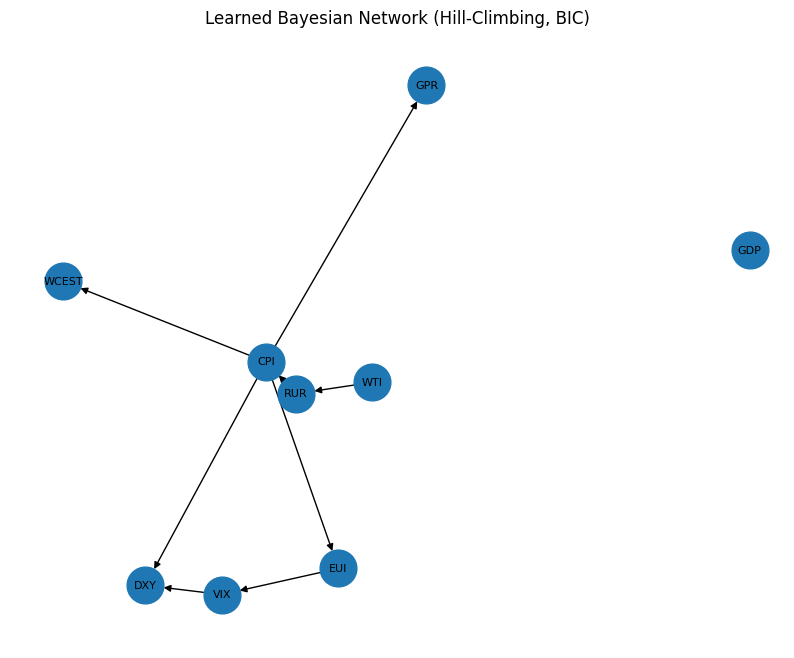

In [8]:
# configration
csv_path = "merged_dataset.csv"
out_edges_csv = "learned_bn_edges_hc_bic.csv"
out_plot_png = "learned_bn_graph.png"

max_na_frac = 0.20       # drop columns with >20% missing
n_bins = 3               # quantile bins for numeric discretization
max_parents = 3          # cap parents per node
max_iters = 50           # HC iterations
random_seed = 42         # for graph layout only

def main():
    # 1) loading the dataset
    if not Path(csv_path).exists():
        raise FileNotFoundError(f"CSV not found at: {csv_path}")
    df = load_and_prepare(csv_path)

    # 2) discretizing the variables
    discretized, state_counts = discretize_dataframe(df, n_bins=n_bins)
    nodes = list(discretized.columns)

    # 3) running the Hill-Climbing model
    edges, best_score, iters = hill_climb_bn(discretized, state_counts, max_parents=max_parents, max_iters=max_iters)

    # 4) reporting the required results
    print("Hill-Climbing completed.")
    print(f"Iterations: {iters}")
    print(f"Final BIC score: {best_score:.2f}")
    print(f"Number of nodes: {len(nodes)}")
    print(f"Number of edges: {len(edges)}")
    print("Learned edges (parent -> child):")
    for u, v in sorted(edges):
        print(f"{u} -> {v}")

    # 5) exporting the required results
    save_edges(edges, out_edges_csv)
    plot_dag(nodes, edges, "Learned Bayesian Network (Hill-Climbing, BIC)", out_png=out_plot_png)

if __name__ == "__main__":
    main()

In [9]:
# defining the required functions for hill climbing using bdeu score

# BDeu scoring (memoized)
class BDeuScorer:
    def __init__(self, data: pd.DataFrame, state_counts: dict[str, int], ess: float):
        self.data = data
        self.r_states = state_counts
        self.ess = ess
        self._node_cache: dict[tuple[str, tuple[str, ...], float], float] = {}

    def node_score(self, var: str, parents: list[str]) -> float:
        key = (var, tuple(sorted(parents)), self.ess)
        if key in self._node_cache:
            return self._node_cache[key]

        r_i = self.r_states[var]

        if len(parents) == 0:
            counts = self.data[var].value_counts().reindex(range(r_i), fill_value=0).values
            alpha = self.ess
            alpha_j = alpha  # q_i = 1
            term = math.lgamma(alpha_j) - math.lgamma(alpha_j + len(self.data))
            for k in range(r_i):
                alpha_jk = alpha / r_i
                term += math.lgamma(alpha_jk + counts[k]) - math.lgamma(alpha_jk)
            self._node_cache[key] = term
            return term

        # parents present
        q_i = 1
        for p in parents:
            q_i *= self.r_states[p]

        alpha = self.ess
        alpha_j = alpha / q_i
        alpha_jk = alpha / (q_i * r_i)

        gb = self.data.groupby(parents + [var]).size().unstack(fill_value=0)
        gb = gb.reindex(columns=range(r_i), fill_value=0)

        term = 0.0
        parent_states = [range(self.r_states[p]) for p in parents]
        for parent_config in product(*parent_states):
            try:
                row = gb.loc[parent_config]
            except KeyError:
                row = pd.Series([0] * r_i, index=range(r_i))
            if not hasattr(row, "index") or len(row) != r_i:
                row = pd.Series([0] * r_i, index=range(r_i))

            N_j = int(row.sum())
            term += math.lgamma(alpha_j) - math.lgamma(alpha_j + N_j)
            for k in range(r_i):
                N_jk = int(row.loc[k]) if k in row.index else 0
                term += math.lgamma(alpha_jk + N_jk) - math.lgamma(alpha_jk)

        self._node_cache[key] = term
        return term

    def network_score(self, edges: set[tuple[str, str]]) -> float:
        parents = {v: [] for v in self.data.columns}
        for u, v in edges:
            parents[v].append(u)
        return sum(self.node_score(var, parents[var]) for var in self.data.columns)


# Hill-Climbing with constraints + random restarts
def hc_bdeu(data: pd.DataFrame, state_counts: dict[str, int], ess: float = 10.0, max_parents: int = 3, max_iters: int = 50,
            blacklist: set[tuple[str, str]] | None = None, whitelist: set[tuple[str, str]] | None = None,
            random_seed: int | None = 42, init_density: float = 0.0, restarts: int = 5) -> tuple[set[tuple[str, str]], float, int]:
    """
    Returns best_edges, best_score, iterations_of_best_run
    """
    rng = random.Random(random_seed)
    nodes = list(data.columns)
    scorer = BDeuScorer(data, state_counts, ess)

    def valid_to_add(u, v, edges):
        if blacklist and (u, v) in blacklist:
            return False
        if parent_count(edges, v) >= max_parents:
            return False
        new_edges = set(edges); new_edges.add((u, v))
        return is_acyclic(nodes, new_edges)

    def valid_to_reverse(u, v, edges):
        if whitelist and (u, v) in whitelist:
            return False  # can't reverse whitelisted edge
        if blacklist and (v, u) in blacklist:
            return False
        if parent_count(edges, u) >= max_parents:
            return False
        new_edges = set(edges); new_edges.remove((u, v)); new_edges.add((v, u))
        return is_acyclic(nodes, new_edges)

    # ensuring whitelisted parents do not exceed cap
    if whitelist:
        parent_map = {}
        for u, v in whitelist:
            parent_map.setdefault(v, set()).add(u)
        for v, ps in parent_map.items():
            if len(ps) > max_parents:
                raise ValueError(f"Whitelist makes {v} have {len(ps)} parents > max_parents({max_parents})")

    best_global_edges: set[tuple[str, str]] = set()
    best_global_score = -float("inf")
    best_global_iters = 0

    for r in range(restarts):
        # initialize edges (optional sparse random)
        edges: set[tuple[str, str]] = set()

        if init_density > 0.0:
            all_pairs = [(u, v) for u, v in permutations(nodes, 2)]
            rng.shuffle(all_pairs)
            target_adds = int(init_density * len(all_pairs))
            for u, v in all_pairs[:target_adds]:
                if valid_to_add(u, v, edges):
                    edges.add((u, v))

        # force whitelist edges in
        if whitelist:
            for u, v in whitelist:
                if (u, v) not in edges:
                    if not valid_to_add(u, v, edges):
                        raise ValueError(f"Whitelisted edge {u}->{v} violates constraints or acyclicity.")
                    edges.add((u, v))

        best = scorer.network_score(edges)
        improved = True
        iters = 0

        while improved and iters < max_iters:
            iters += 1
            improved = False
            current_best = best
            current_best_edges = None

            # ADD moves
            add_moves = [(u, v) for u, v in permutations(nodes, 2) if (u, v) not in edges]
            rng.shuffle(add_moves)
            for u, v in add_moves:
                if not valid_to_add(u, v, edges):
                    continue
                new_edges = set(edges); new_edges.add((u, v))
                s = scorer.network_score(new_edges)
                if s > current_best + 1e-12:
                    current_best = s
                    current_best_edges = new_edges

            # DELETE moves (not permitted on whitelist)
            del_moves = list(edges)
            rng.shuffle(del_moves)
            for e in del_moves:
                if whitelist and e in whitelist:
                    continue
                new_edges = set(edges); new_edges.remove(e)
                s = scorer.network_score(new_edges)
                if s > current_best + 1e-12:
                    current_best = s
                    current_best_edges = new_edges

            # REVERSE moves
            rev_moves = list(edges)
            rng.shuffle(rev_moves)
            for (u, v) in rev_moves:
                if not valid_to_reverse(u, v, edges):
                    continue
                new_edges = set(edges); new_edges.remove((u, v)); new_edges.add((v, u))
                s = scorer.network_score(new_edges)
                if s > current_best + 1e-12:
                    current_best = s
                    current_best_edges = new_edges

            if current_best_edges is not None:
                edges = current_best_edges
                best = current_best
                improved = True

        if best > best_global_score:
            best_global_edges, best_global_score, best_global_iters = edges, best, iters

    return best_global_edges, best_global_score, best_global_iters

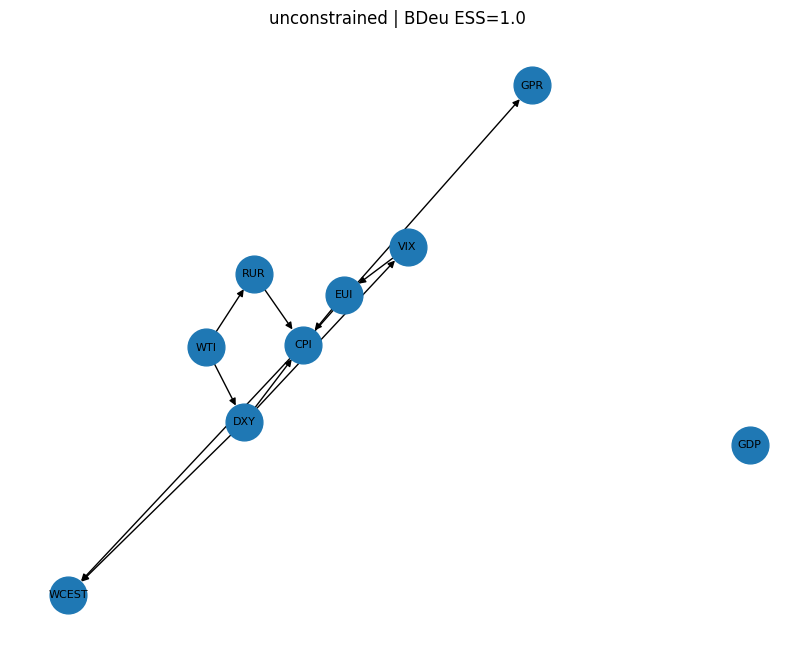

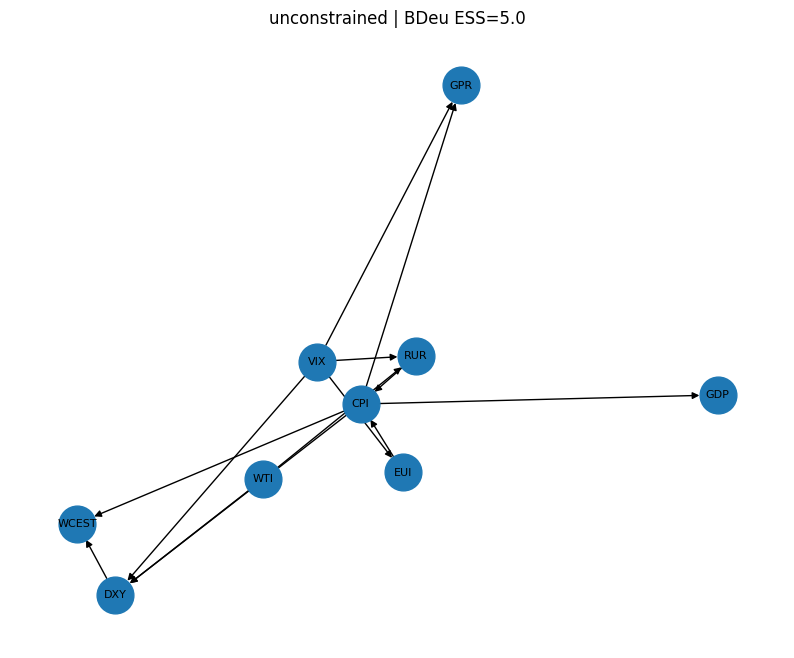

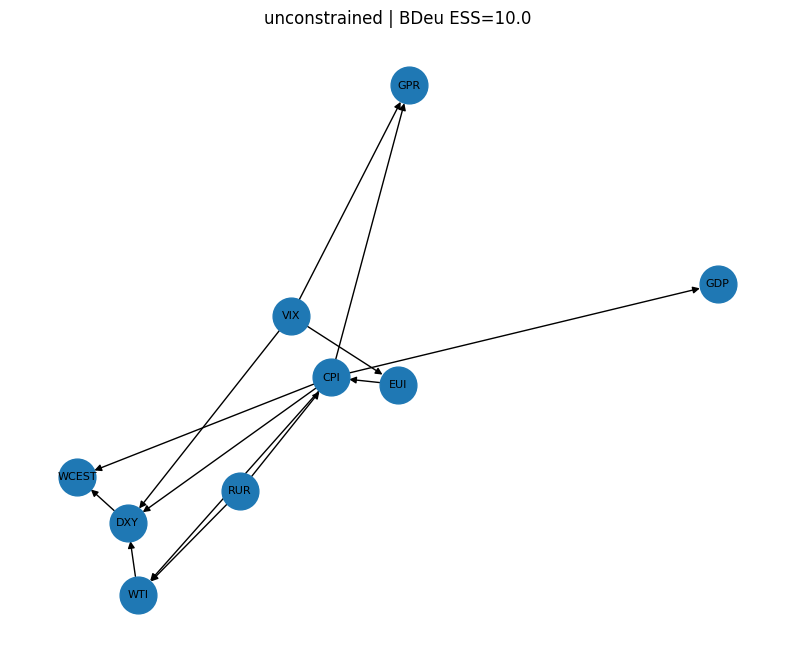

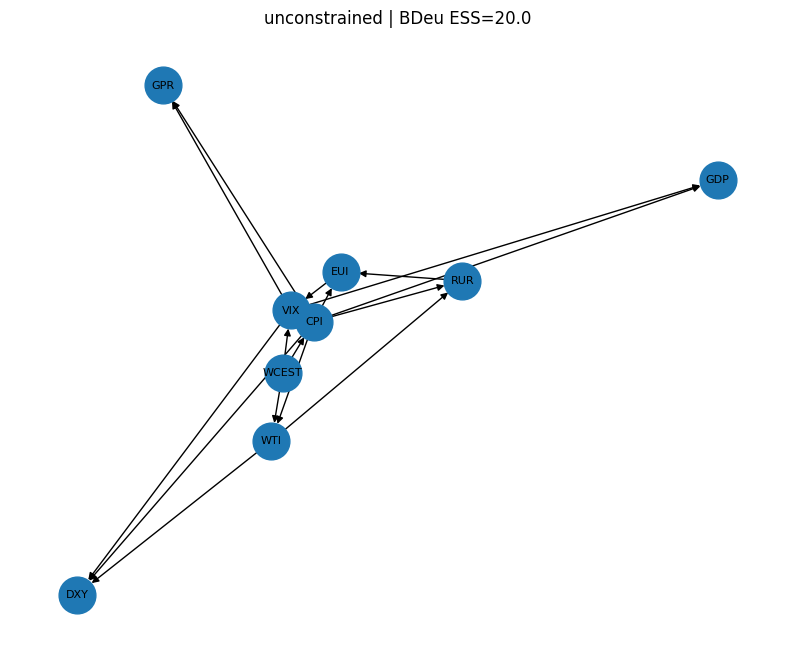

         mode  ess  max_parents  max_iters  restarts  init_density  n_nodes  n_edges        score                                     edges_csv                                     graph_png
unconstrained  1.0            3         50         5           0.0        9       10 -1704.793175  bn_outputs/edges_unconstrained_bdeu_ess1.csv  bn_outputs/graph_unconstrained_bdeu_ess1.png
unconstrained  5.0            3         50         5           0.0        9       13 -1646.192208  bn_outputs/edges_unconstrained_bdeu_ess5.csv  bn_outputs/graph_unconstrained_bdeu_ess5.png
unconstrained 10.0            3         50         5           0.0        9       13 -1630.355908 bn_outputs/edges_unconstrained_bdeu_ess10.csv bn_outputs/graph_unconstrained_bdeu_ess10.png
unconstrained 20.0            3         50         5           0.0        9       16 -1623.576730 bn_outputs/edges_unconstrained_bdeu_ess20.csv bn_outputs/graph_unconstrained_bdeu_ess20.png


In [10]:
# Run modes & CLI
def run_modes(csv_path: str, out_dir: str = "bn_outputs", ess_values: list[float] = [1.0, 5.0, 10.0, 20.0],
              max_parents: int = 3, max_iters: int = 50, restarts: int = 5, init_density: float = 0.0, n_bins: int = 3):

    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    # 1) data
    df = load_and_prepare(csv_path)
    disc, state_counts = discretize_dataframe(df, n_bins=n_bins)
    nodes = list(disc.columns)

    # Define modes
    modes = []

    # Unconstrained
    modes.append(("unconstrained", set(), set()))
    summary_rows = []

    # 2) sweeps
    for mode_name, blacklist, whitelist in modes:
        for ess in ess_values:
            edges, score, iters = hc_bdeu(disc, state_counts, ess=ess, max_parents=max_parents, max_iters=max_iters, blacklist=blacklist,
                                          whitelist=whitelist, random_seed=42, init_density=init_density, restarts=restarts)

            # save outputs
            edge_csv = out / f"edges_{mode_name}_bdeu_ess{int(ess)}.csv"
            png_path = out / f"graph_{mode_name}_bdeu_ess{int(ess)}.png"
            save_edges(edges, edge_csv)
            plot_dag(nodes, edges, f"{mode_name} | BDeu ESS={ess}", png_path)

            summary_rows.append({"mode": mode_name, "ess": ess, "max_parents": max_parents, "max_iters": max_iters, "restarts": restarts,
                                 "init_density": init_density, "n_nodes": len(nodes), "n_edges": len(edges), "score": score,
                                 "edges_csv": str(edge_csv), "graph_png": str(png_path)})

    summary_df = pd.DataFrame(summary_rows)
    summary_path = out / "bdeu_runs_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print(summary_df.sort_values(["mode", "ess"]).to_string(index=False))


def parse_args():
    p = argparse.ArgumentParser(description="BN Hill-Climbing with BDeu scoring")
    p.add_argument("--csv", default="merged_dataset.csv")
    p.add_argument("--out", default="bn_outputs")
    p.add_argument("--ess", nargs="+", type=float, default=[1.0, 5.0, 10.0, 20.0])
    p.add_argument("--max_parents", type=int, default=3)
    p.add_argument("--max_iters", type=int, default=50)
    p.add_argument("--restarts", type=int, default=5)
    p.add_argument("--init_density", type=float, default=0.0)
    p.add_argument("--n_bins", type=int, default=3)
    p.add_argument("--keep_index_cols", action="store_true")
    # <-- THIS is the fix: ignore unknown notebook args like -f ...
    args, _ = p.parse_known_args()
    return args



if __name__ == "__main__":
    args = parse_args()
    run_modes(csv_path=args.csv, out_dir=args.out, ess_values=args.ess, max_parents=args.max_parents,
              max_iters=args.max_iters, restarts=args.restarts, init_density=args.init_density, n_bins=args.n_bins)

## **Step 5**

In [20]:
# defining the required columns for evaluation and testing

# feature set and target set
def build_xy(df: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, pd.Series]:

    df = df.dropna(subset=[target_col]).copy()
    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()

    X = X.ffill().bfill()
    y = df[target_col].astype(float)
    X, y = X.loc[y.index], y.loc[X.index]

    X.index = pd.to_datetime(X.index)
    y.index = pd.to_datetime(y.index)

    return X, y

# training, evaluating, plotting
def run_baseline_forecast(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    # chronological split (shuffle=False)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_test, y_pred))

    return {"model": model, "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test,
            "y_pred": pd.Series(y_pred, index=y_test.index), "rmse": rmse, "r2": r2}

def plot_actual_vs_pred(y_test: pd.Series, y_pred: pd.Series, out_png: Path | None):
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test.values, label="Actual WTI Price")
    plt.plot(y_pred.index, y_pred.values, label="Predicted WTI Price", linestyle="--")
    plt.title("Actual vs Predicted Crude Oil Prices (WTI)")
    plt.xlabel("Time Index")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

    # Format x-axis dates
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    if out_png:
        out_png.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_png, bbox_inches="tight", dpi=150)
    plt.show()

=== Forecast accuracy (test set) ===
RMSE: 5.6709
R²  : 0.8759
Test sample size: 43


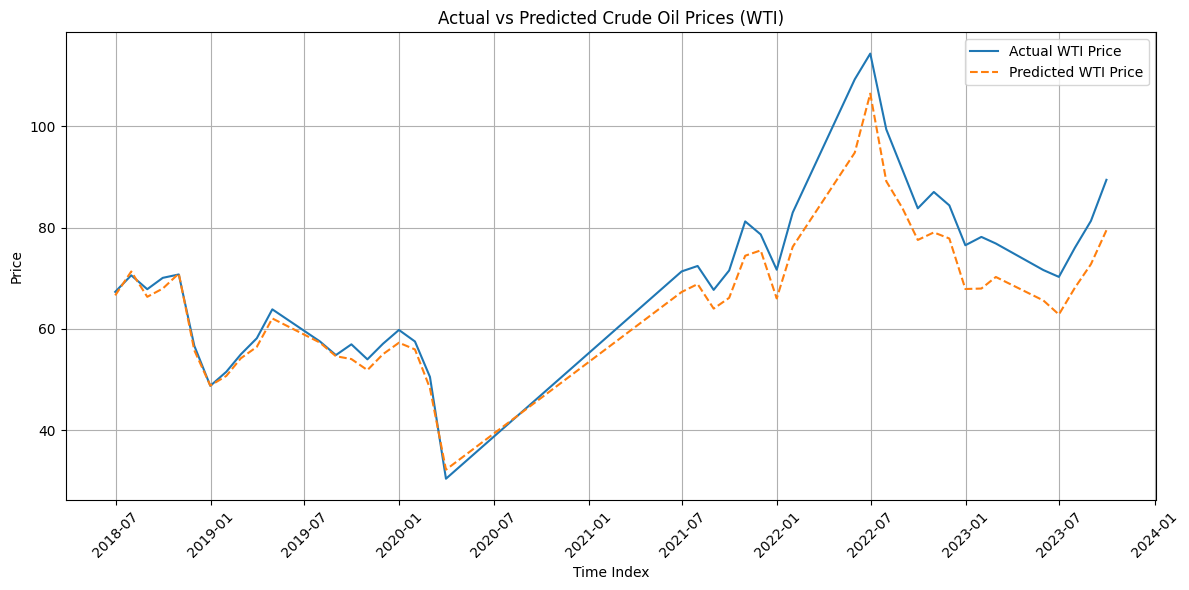

In [21]:
# dataset and configuration
csv_path = "merged_dataset.csv"
out_dir = Path("forecast_outputs")
plot_png = out_dir / "wti_actual_vs_pred.png"
metrics_csv = out_dir / "wti_metrics.csv"
predictions_csv = out_dir / "wti_test_predictions.csv"
test_size = 0.20
target_col = "WTI"

def main():
    out_dir.mkdir(parents=True, exist_ok=True)

    df = load_and_prepare(csv_path)
    X, y = build_xy(df, target_col)
    res = run_baseline_forecast(X, y, test_size=test_size)

    # printing required metrics
    print("=== Forecast accuracy (test set) ===")
    print(f"RMSE: {res['rmse']:.4f}")
    print(f"R²  : {res['r2']:.4f}")
    print(f"Test sample size: {len(res['y_test'])}")

    # saving metrics and predictions
    pd.DataFrame([{"rmse": res["rmse"], "r2": res["r2"], "test_size": len(res["y_test"])}]).to_csv(metrics_csv, index=False)
    pred_df = pd.DataFrame({"actual_wti": res["y_test"].values, "predicted_wti": res["y_pred"].values}, index=res["y_test"].index)
    pred_df.to_csv(predictions_csv, index_label="row_index")

    # plotting
    plot_actual_vs_pred(res["y_test"], res["y_pred"], plot_png)

if __name__ == "__main__":
    main()